In [2]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12, 6]

In [4]:
# COSTANTI
m, L, g = 1, 1, 9.81
theta0, omega0 = 0.5, 0.0
t1, t2, t3, h = 20, 500, 10, 0.01
gL = g/L
ver_color = "#ed184d"
rk4_color = "#187bed"

In [5]:
times = np.arange(0, t1, h)
long_times = np.arange(0, t2, h)
hs = np.array([0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001])

In [6]:
def verlet(theta0: float, h: float, times: list[float]) -> tuple[list[float], list[float]]:
    a0 = -gL * np.sin(theta0)
    h_mezzi, h_quadro_mezzi = h/2, h**2/2
    pos, vel = np.zeros(len(times)), np.zeros(len(times))
    pos[0], vel[0] = theta0, omega0

    for i in range(1, len(times)):
        pos[i] = pos[i-1] + h * vel[i-1] + h_quadro_mezzi * a0
        a = -gL * np.sin(pos[i])
        vel[i] = vel[i-1] + h_mezzi * (a0 + a)

        a0 = a

    return pos, vel

def rk4(theta0: float, h: float, times: list[float]) -> tuple[list[float], list[float]]:
    h_mezzi, h_sesti = h/2, h/6
    pos, vel = np.zeros(len(times)), np.zeros(len(times))
    pos[0], vel[0] = theta0, omega0

    for i in range(1, len(times)):
        k1t, k1o = vel[i-1], -gL * np.sin(pos[i-1])
        k2t, k2o = vel[i-1] + h_mezzi * k1o, -gL * np.sin(pos[i-1] + h_mezzi * k1t)
        k3t, k3o = vel[i-1] + h_mezzi * k2o, -gL * np.sin(pos[i-1] + h_mezzi * k2t)
        k4t, k4o = vel[i-1] + h * k3o, -gL * np.sin(pos[i-1] + h * k3t)

        pos[i] = pos[i-1] + h_sesti * (k1t + 2*k2t + 2*k3t + k4t)
        vel[i] = vel[i-1] + h_sesti * (k1o + 2*k2o + 2*k3o + k4o)
        
    return pos, vel

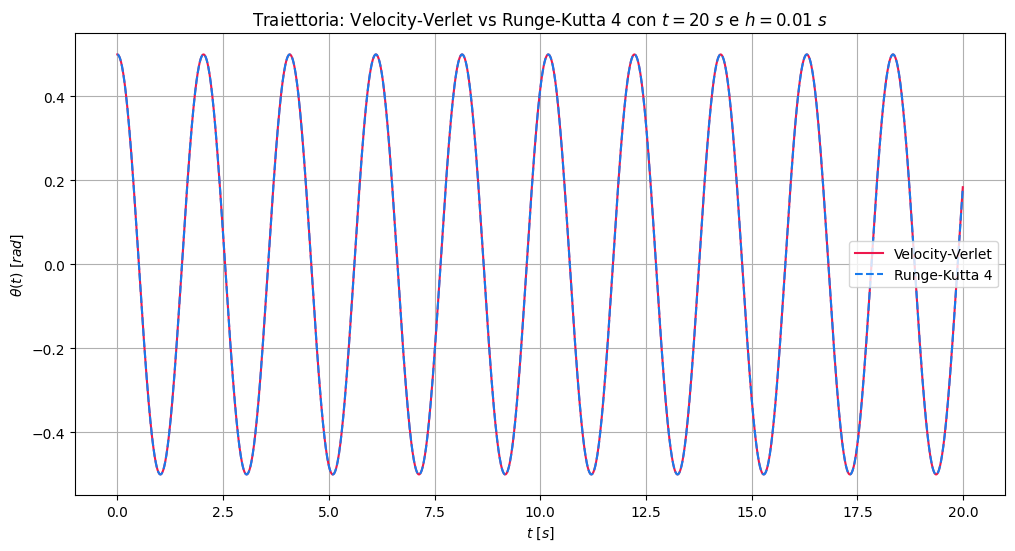

In [7]:
ver_pos, ver_vel = verlet(theta0=theta0, h=h, times=times)
rk4_pos, rk4_vel = rk4(theta0=theta0, h=h, times=times)

plt.plot(times, ver_pos, color=ver_color, label="Velocity-Verlet")
plt.plot(times, rk4_pos, "--", color=rk4_color, label="Runge-Kutta 4")
plt.xlabel(r"$t\ [s]$")
plt.ylabel(r"$\theta(t)\ [rad]$")
plt.grid()
plt.legend()
plt.title(r"Traiettoria: Velocity-Verlet vs Runge-Kutta 4 con $t=20\ s$ e $h=0.01\ s$")
plt.show()

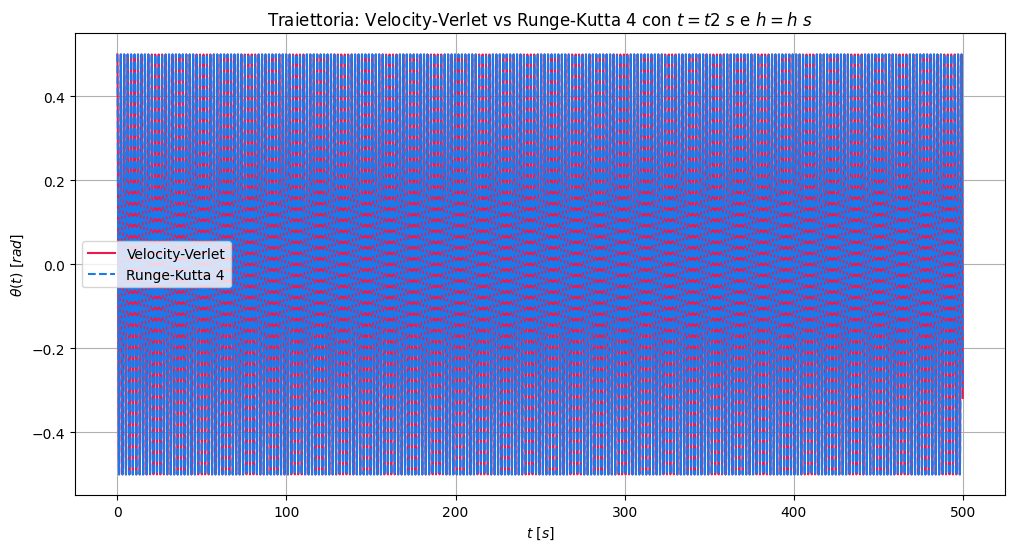

In [8]:
l_ver_pos, l_ver_vel = verlet(theta0=theta0, h=h, times=long_times)
l_rk4_pos, l_rk4_vel = rk4(theta0=theta0, h=h, times=long_times)

plt.plot(long_times, l_ver_pos, color=ver_color, label="Velocity-Verlet")
plt.plot(long_times, l_rk4_pos, "--", color=rk4_color, label="Runge-Kutta 4")
plt.xlabel(r"$t\ [s]$")
plt.ylabel(r"$\theta(t)\ [rad]$")
plt.grid()
plt.legend()
plt.title(r"Traiettoria: Velocity-Verlet vs Runge-Kutta 4 con $t={t2}\ s$ e $h={h}\ s$")
plt.show()

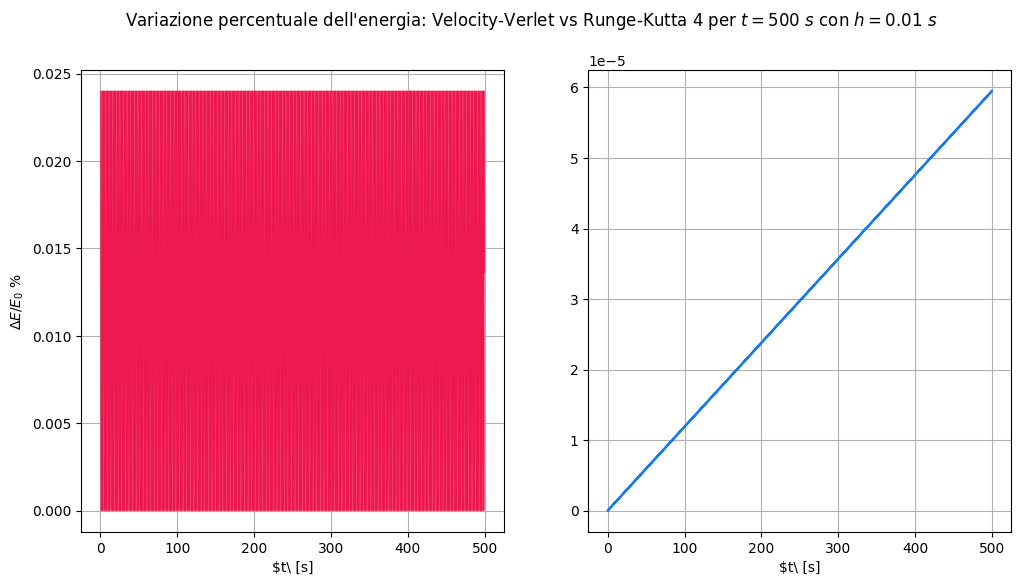

In [9]:
# ENERGIE
ver_energy = 0.5 * m * L**2 * l_ver_vel**2 + m * g * L * (1 - np.cos(l_ver_pos))
rk4_energy = 0.5 * m * L**2 * l_rk4_vel**2 + m * g * L * (1 - np.cos(l_rk4_pos))
energy = [0.5 * m * L**2 * omega0**2 + m * g * L * (1 - np.cos(theta0)) for _ in long_times]

delta_ver_energy = abs(ver_energy - energy)
delta_rk4_energy = abs(rk4_energy - energy)

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(long_times, 100*delta_ver_energy/energy, color=ver_color, label="Velocity-Verlet", lw=0.3)
ax1.set_xlabel(r"$t\ [s]")
ax1.set_ylabel(r"$\Delta E/E_0\ \%$")
ax1.grid(True)

ax2.plot(long_times, 100*delta_rk4_energy/energy, color=rk4_color, label="Runge-Kutta 4")
ax2.set_xlabel(r"$t\ [s]")
ax2.grid(True)

plt.suptitle(rf"Variazione percentuale dell'energia: Velocity-Verlet vs Runge-Kutta 4 per $t={t2}\ s$ con $h={h}\ s$")
plt.show()

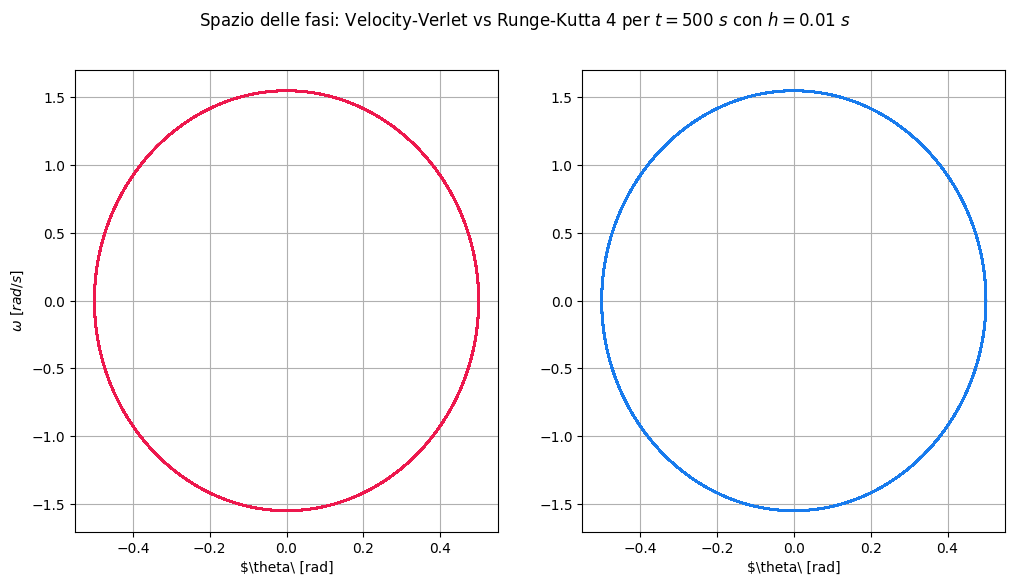

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(l_ver_pos, l_ver_vel, color=ver_color, label="Velocity-Verlet")
ax1.set_xlabel(r"$\theta\ [rad]")
ax1.set_ylabel(r"$\omega\ [rad/s]$")
ax1.grid(True)

ax2.plot(l_rk4_pos, l_rk4_vel, color=rk4_color, label="Runge-Kutta 4")
ax2.set_xlabel(r"$\theta\ [rad]")
ax2.grid(True)

plt.suptitle(rf"Spazio delle fasi: Velocity-Verlet vs Runge-Kutta 4 per $t={t2}\ s$ con $h={h}\ s$")
plt.show()

In [11]:
def compute_error(hs: list[float], f: callable, camp: float) -> list[float]:
    errs = np.zeros(len(hs))
    for i in range(len(hs)):
        t = np.linspace(0, 10, int(10/hs[i])+1)
        pos, vel = f(theta0=theta0, h=hs[i], times=t)
        err = abs(pos[-1] - camp)
        errs[i] = err

    return errs

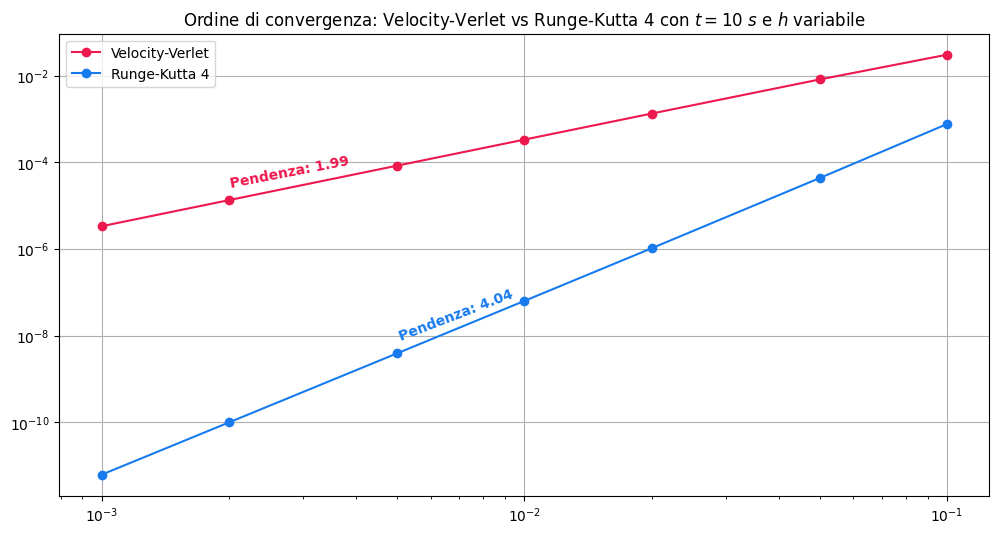

In [27]:
t10 = np.linspace(0, 10, int(10/0.0001)+1)
rif, _ = rk4(theta0=theta0, h=0.0001, times=t10)
camp = rif[-1]

ver_err = compute_error(hs=hs, f=verlet, camp=camp)
rk4_err = compute_error(hs=hs, f=rk4, camp=camp)
log_h, log_ver_err, log_rk4_err = np.log(hs), np.log(ver_err), np.log(rk4_err)

m_ver, _ = np.polyfit(log_h, log_ver_err, 1)
m_rk4, _ = np.polyfit(log_h, log_rk4_err, 1)

plt.plot(hs, ver_err, "-o", color=ver_color, label="Velocity-Verlet")
plt.plot(hs, rk4_err, "-o", color=rk4_color, label="Runge-Kutta 4")
plt.text(hs[-2], ver_err[-2]*2, f"Pendenza: {m_ver:.2f}", color=ver_color, fontweight="bold", rotation=11)
plt.text(hs[-3], rk4_err[-3]*2, f"Pendenza: {m_rk4:.2f}", color=rk4_color, fontweight="bold", rotation=21)
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.legend()
plt.title(rf"Ordine di convergenza: Velocity-Verlet vs Runge-Kutta 4 con $t=10\ s$ e $h$ variabile")
plt.show()